In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

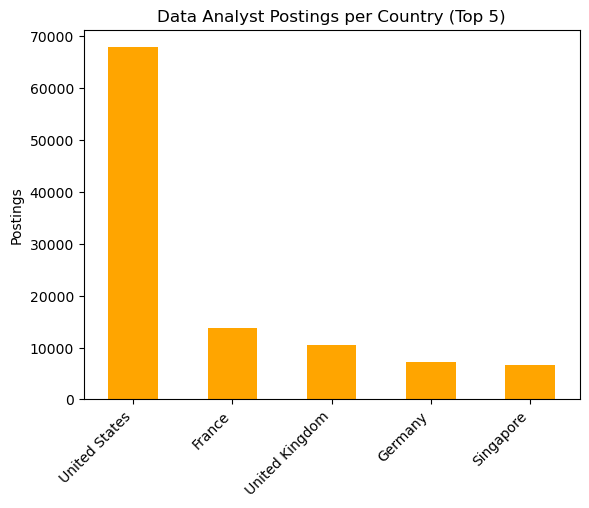

In [29]:
country_job_postings = df.pivot_table(index='job_country', columns='job_title_short', aggfunc='size')

top_countires_data_analyst_postings = country_job_postings['Data Analyst'].sort_values(ascending=False).head(5)

top_countires_data_analyst_postings.plot(kind='bar', color='orange')
plt.title('Data Analyst Postings per Country (Top 5)')
plt.ylabel('Postings')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.show()

In [36]:
company_salary_info = df.pivot_table(index='company_name', aggfunc={'salary_year_avg': ['min', 'mean', 'max']})
company_salary_info.head(5)

salary_year_avg                              
                                    max           mean            min
company_name                                                         
#twiceasnice Recruiting   120000.000000   77750.000000   61000.000000
/dev/color                125000.000000  125000.000000  125000.000000
0nward Select              92500.000000   92500.000000   92500.000000
1 Point System            137290.484375  137290.484375  137290.484375
1 Point System LLC.       170000.000000  170000.000000  170000.000000

In [70]:
df_data_scientist = df[df['job_title_short'] == 'Data Scientist'].copy()
my_pivot_table = df_data_scientist.pivot_table(values='salary_year_avg', aggfunc='median', index=['company_name', 'job_country'])
my_pivot_table = my_pivot_table[my_pivot_table['salary_year_avg'] > 200_000]
my_pivot_table.head(10)

salary_year_avg
company_name        job_country                   
ACT                 Sudan                 225000.0
                    United States         225000.0
Abbott              United States         204000.0
Airbnb              United States         212500.0
Airtable            Sudan                 215500.0
                    United States         233500.0
Algo Capital Group  Sudan                 325000.0
                    United States         350000.0
Amadeus Search      United States         232500.0
Analog Devices, Inc United States         375000.0